# 06 — Ground Truth Validation
Compare the YOLO-derived heatmap against a heatmap built from the annotated GT head positions.

In [49]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat
import seaborn as sns

sys.path.insert(0, '..')
from src.heatmap import FLOOR_W, FLOOR_H, SIGMA, make_floor_canvas, project_points, build_heatmap

sns.set_theme(style='whitegrid')

RAW       = Path('../data/raw')
PROCESSED = Path('../data/processed')

H = np.load(PROCESSED / 'homography.npy')

## Extract GT head positions across all frames

In [50]:
gt = loadmat(RAW / 'mall_gt.mat')

rows = []
for i in range(gt['frame'].shape[1]):
    heads = gt['frame'][0, i][0, 0][0]  # (N, 2) float — (x, y) head positions
    for x, y in heads:
        rows.append({'frame_id': i + 1, 'x': x, 'y': y})

gt_df = pd.DataFrame(rows)
print(f'Total GT head positions: {len(gt_df)} across {gt_df["frame_id"].nunique()} frames')
print(gt_df.head())

Total GT head positions: 62315 across 2000 frames
   frame_id           x          y
0         1  126.779863  60.704778
1         1  116.950512  47.598976
2         1  175.107509  44.322526
3         1  184.117747  45.141638
4         1  192.308874  44.322526


## Calibrate head-to-foot pixel model from YOLO bounding box heights

YOLO bounding box heights from all 2,000 frames give us the person pixel height
at each image y position. A k-NN lookup (k=50) on y gives a smooth, perspective-correct
δ(v) without any binning choices.

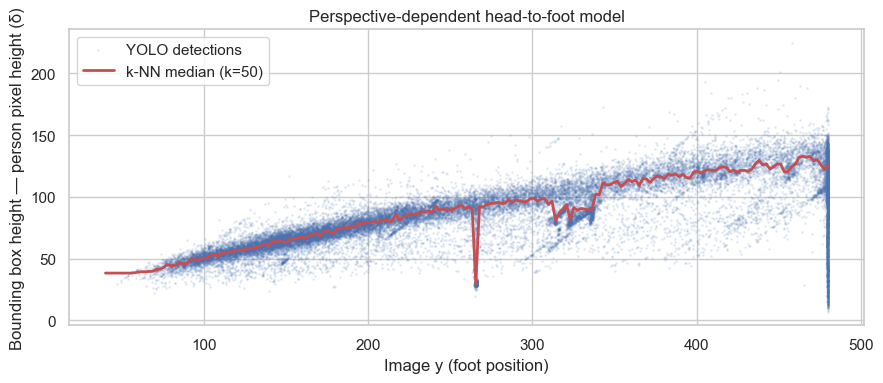

δ at v=380 (near camera): 117 px
δ at v=150 (far):         65 px


In [51]:
from scipy.spatial import cKDTree

bbox_df = pd.read_csv(PROCESSED / '../interim/detections_bbox.csv')

# k-NN on foot y → median bbox height gives δ(v) for any query y
knn_tree = cKDTree(bbox_df[['y']].values)

def delta_fn(v_arr):
    v_arr = np.atleast_1d(v_arr).reshape(-1, 1)
    _, idxs = knn_tree.query(v_arr, k=50)
    return np.median(bbox_df['bbox_h'].values[idxs], axis=1)

v_range = np.linspace(40, 480, 200)
delta_vals = delta_fn(v_range)

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(bbox_df['y'], bbox_df['bbox_h'], s=1, alpha=0.1, label='YOLO detections')
ax.plot(v_range, delta_vals, 'r-', lw=2, label='k-NN median (k=50)')
ax.set_xlabel('Image y (foot position)')
ax.set_ylabel('Bounding box height — person pixel height (δ)')
ax.set_title('Perspective-dependent head-to-foot model')
ax.legend()
plt.tight_layout()
plt.show()

print(f'δ at v=380 (near camera): {delta_fn([380])[0]:.0f} px')
print(f'δ at v=150 (far):         {delta_fn([150])[0]:.0f} px')

## Project GT positions to floor plan

Each GT head at image `(u, v)` is shifted to its estimated foot position `(u, v + δ(v))`
before projecting through H. This makes the correction perspective-correct: δ is larger
for near people and smaller for distant ones, matching how perspective compression works.

In [52]:
pts_img = gt_df[['x', 'y']].values.copy()
pts_img[:, 1] = pts_img[:, 1] + delta_fn(pts_img[:, 1])  # shift head → estimated foot

proj = project_points(pts_img, H)

gt_df['px'] = proj[:, 0]
gt_df['py'] = proj[:, 1]

in_bounds = gt_df['px'].between(0, FLOOR_W) & gt_df['py'].between(0, FLOOR_H)
gt_proj = gt_df[in_bounds].copy()

print(f'In-bounds: {len(gt_proj)} / {len(gt_df)} ({in_bounds.mean()*100:.1f}%)')

In-bounds: 60669 / 62315 (97.4%)


## Build GT and YOLO heatmaps

In [53]:
yolo_proj = pd.read_csv(PROCESSED / 'projected_detections.csv')

heatmap_gt   = build_heatmap(gt_proj)
heatmap_yolo = build_heatmap(yolo_proj)

print(f'GT   heatmap shape: {heatmap_gt.shape}')
print(f'YOLO heatmap shape: {heatmap_yolo.shape}')

GT   heatmap shape: (1200, 820)
YOLO heatmap shape: (1200, 820)


## Side-by-side comparison

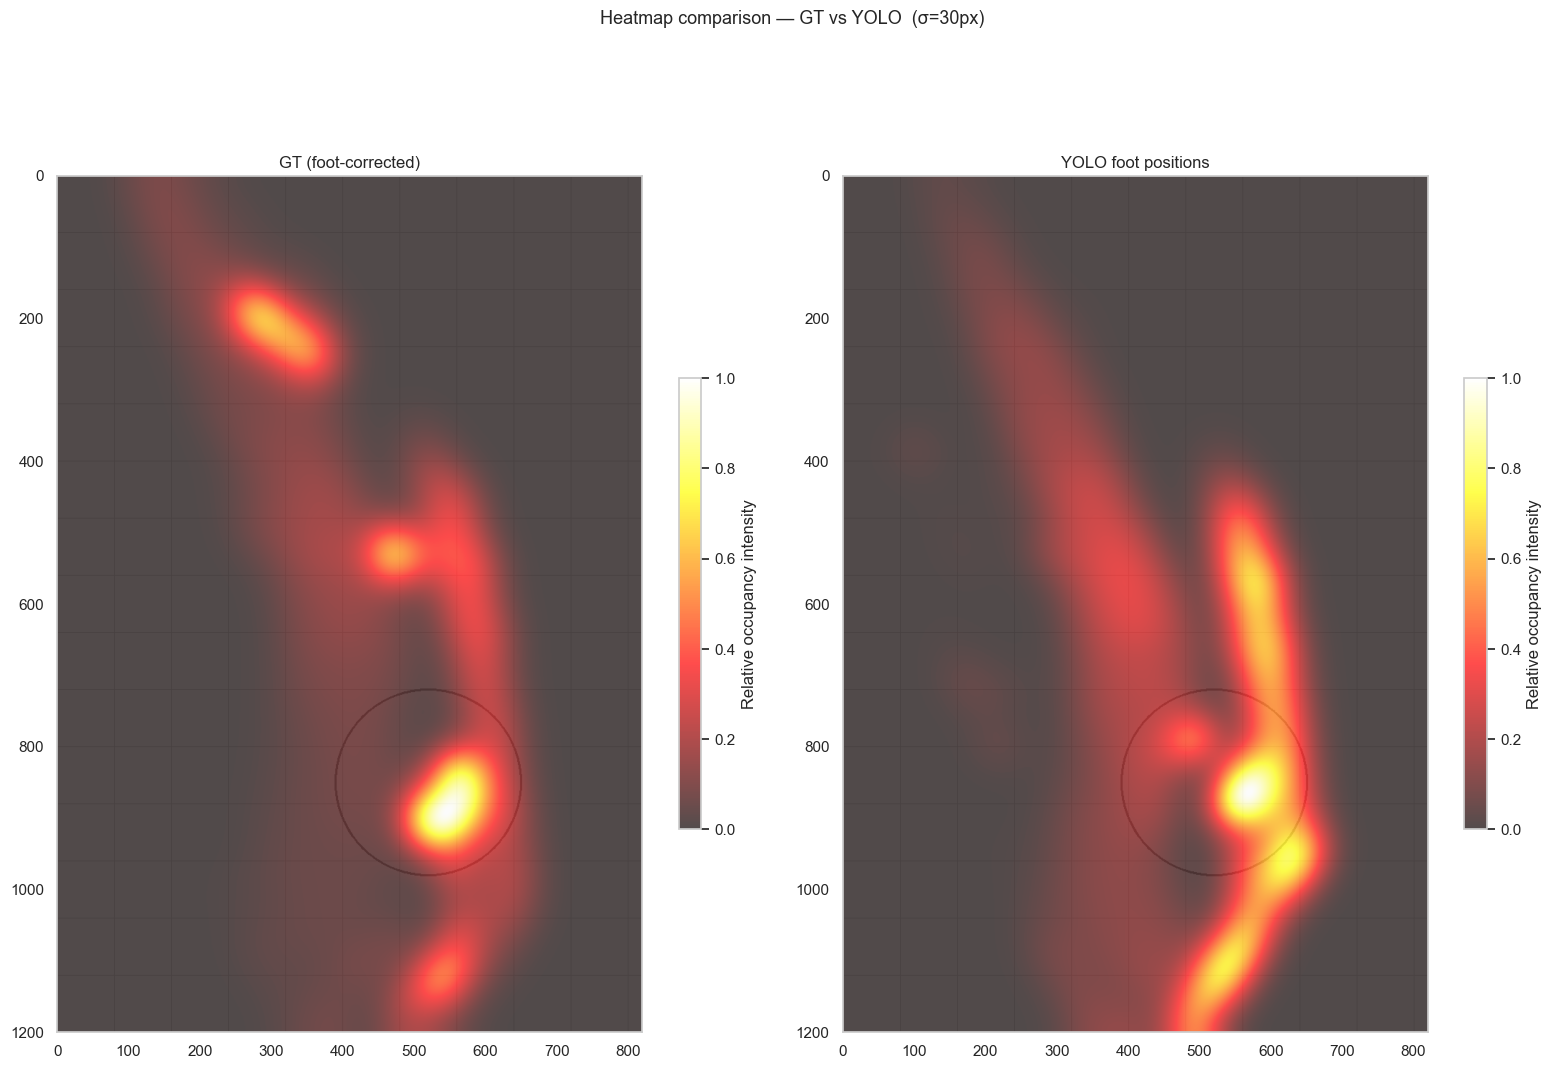

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 12))

titles = ['GT (foot-corrected)', 'YOLO foot positions']
heatmaps = [heatmap_gt, heatmap_yolo]

for ax, hm, title in zip(axes, heatmaps, titles):
    ax.imshow(make_floor_canvas(), extent=[0, FLOOR_W, FLOOR_H, 0])
    im = ax.imshow(hm, extent=[0, FLOOR_W, FLOOR_H, 0],
                   cmap='hot', alpha=0.7, vmin=0, vmax=1)
    plt.colorbar(im, ax=ax, label='Relative occupancy intensity', shrink=0.4)
    ax.grid(False)
    ax.set_title(title, fontsize=12)

plt.suptitle(f'Heatmap comparison — GT vs YOLO  (σ={SIGMA}px)', fontsize=13)
plt.tight_layout()
plt.show()

## Pixel-level difference map

Signed difference `YOLO − GT`. Positive (warm) = YOLO detects more;
negative (cool) = YOLO misses relative to GT.

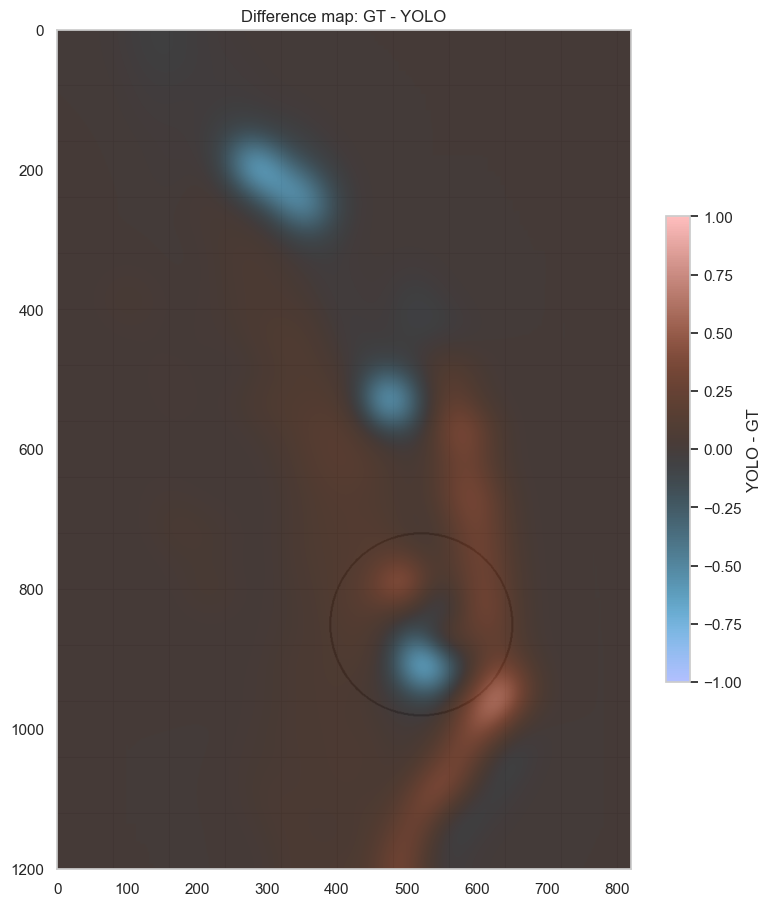

Mean absolute difference: 0.0479
Max over-detection:  0.5642   Max under-detection: -0.5637


In [55]:
diff = heatmap_yolo - heatmap_gt

fig, ax = plt.subplots(figsize=(8, 12))
ax.imshow(make_floor_canvas(), extent=[0, FLOOR_W, FLOOR_H, 0])
im = ax.imshow(diff, extent=[0, FLOOR_W, FLOOR_H, 0],
               cmap='berlin', alpha=0.8,
               vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, label='YOLO - GT', shrink=0.4)
ax.grid(False)
ax.set_title('Difference map: GT - YOLO', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Mean absolute difference: {np.abs(diff).mean():.4f}')
print(f'Max over-detection:  {diff.max():.4f}   Max under-detection: {diff.min():.4f}')